# Importing necessary libraries and dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sample_data/hotel_booking.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860


# Understanding the dataset

In [ ]:
df.shape

(119390, 36)

In [ ]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# Basic Counting/Proportions related graphs

In [ ]:
df['hotel'].value_counts()

,count
hotel,
City Hotel,79330
Resort Hotel,40060


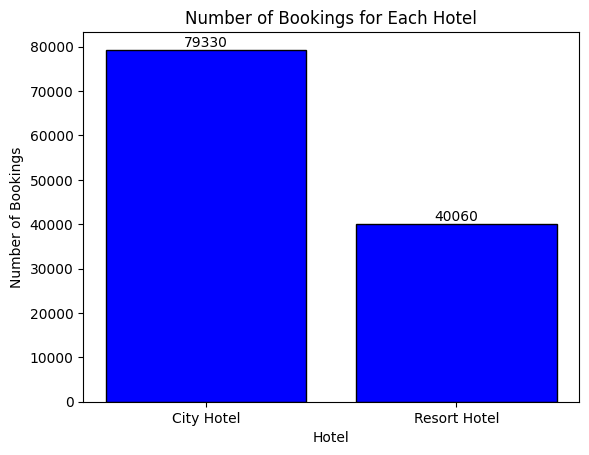

In [ ]:
hotel_wise_bookings = df['hotel'].value_counts()
x = hotel_wise_bookings.index
y = hotel_wise_bookings.values
plt.bar(x, y, color='blue', edgecolor='black')
plt.xlabel('Hotel')
plt.ylabel('Number of Bookings')
plt.title('Number of Bookings for Each Hotel')
plt.bar_label(plt.gca().containers[0])
plt.show()

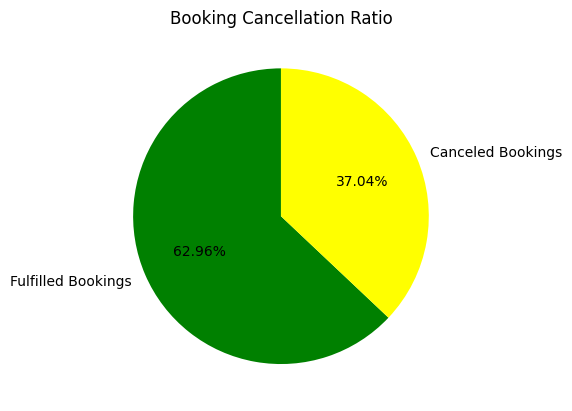

In [ ]:
cancel = df['is_canceled'].value_counts()
cancel.index = cancel.index.map({0: 'Fulfilled Bookings', 1: 'Canceled Bookings'})
x = cancel.index
y = cancel.values
plt.pie(y, labels=x, autopct='%1.2f%%', startangle=90, colors=['green', 'yellow'])
plt.title('Booking Cancellation Ratio')
plt.show()

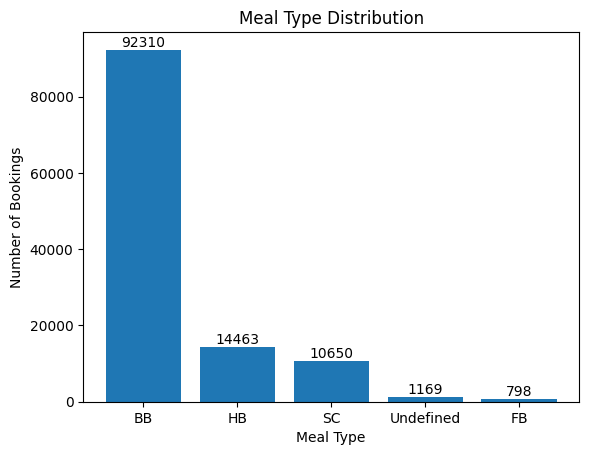

In [ ]:
meal_type = df['meal'].value_counts()
x = meal_type.index
y = meal_type.values
plt.bar(x, y)
plt.title('Meal Type Distribution')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

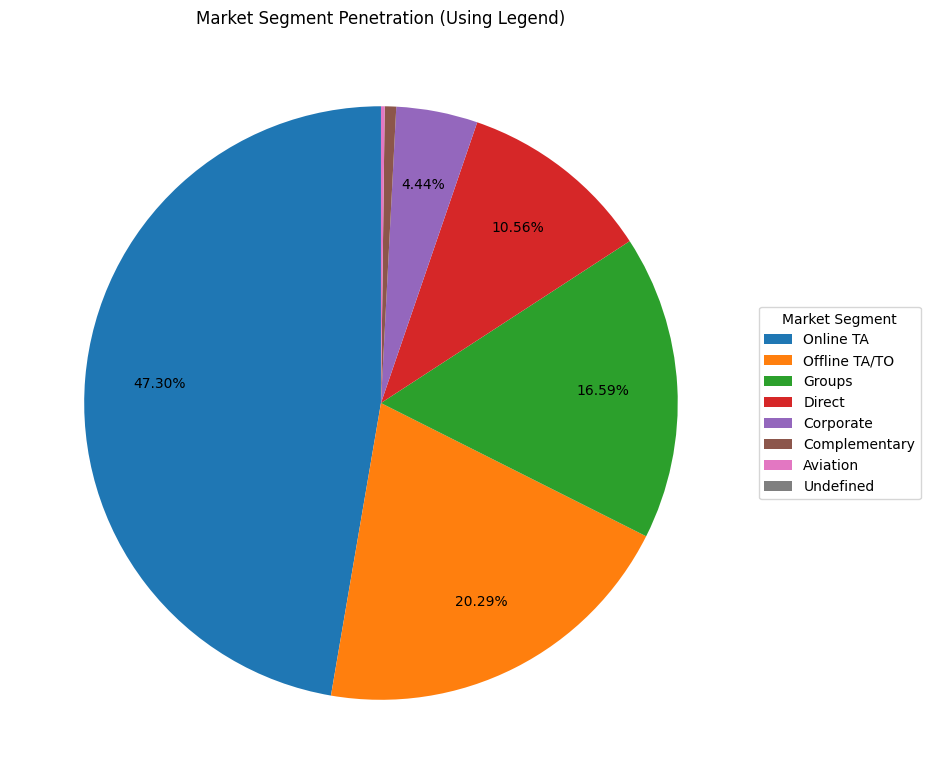

In [ ]:
market = df['market_segment'].value_counts()
x = market.index
y = market.values

plt.figure(figsize=(9, 8))
plt.pie(
    y,
    autopct=lambda pct: f'{pct:1.2f}%' if pct > 2 else '',
    startangle=90,
    pctdistance=0.75,
)

plt.legend(x, title='Market Segment', loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Market Segment Penetration (Using Legend)')
plt.tight_layout()
plt.show()

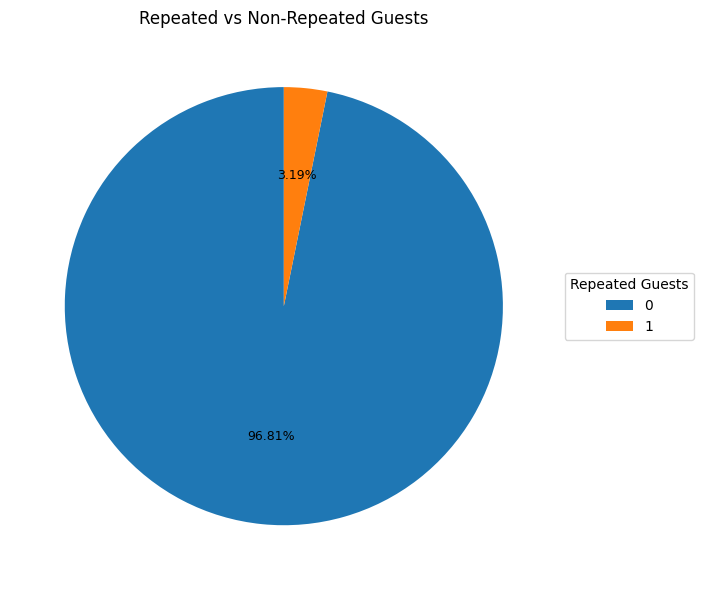

In [ ]:
repeated_guests = df['is_repeated_guest'].value_counts()
x = repeated_guests.index
y = repeated_guests.values

plt.figure(figsize=(7, 6))
plt.pie(
    y,
    autopct=lambda pct: f'{pct:1.2f}%',
    startangle=90,
    textprops={'fontsize': 9}
)

plt.legend(x, title='Repeated Guests', loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Repeated vs Non-Repeated Guests')
plt.tight_layout()
plt.show()

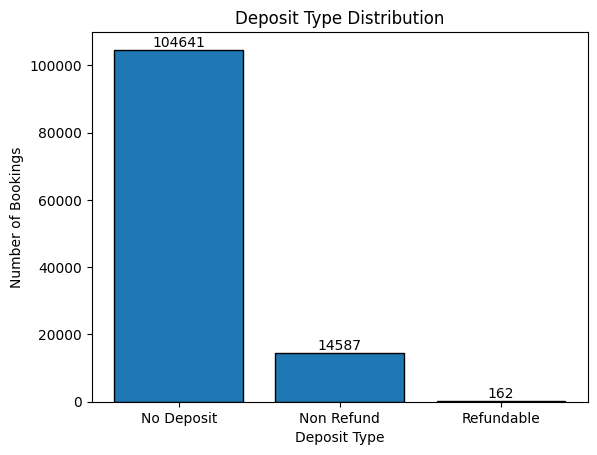

In [ ]:
deposit_type = df['deposit_type'].value_counts()

x = deposit_type.index
y = deposit_type.values

plt.bar(x, y, edgecolor='black')
plt.title('Deposit Type Distribution')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()


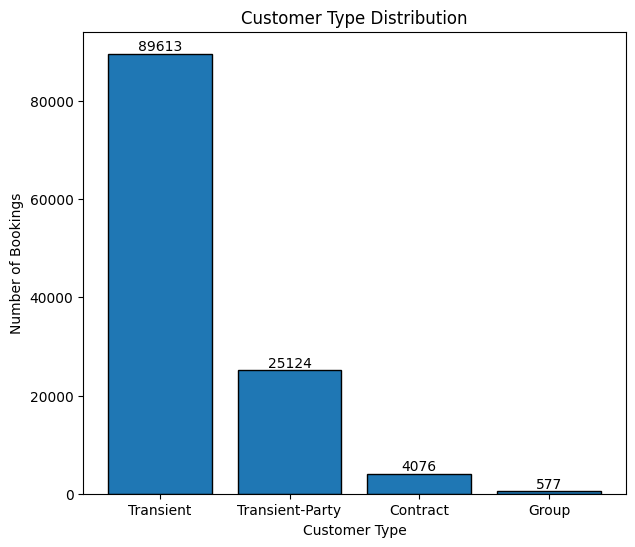

In [ ]:
customer_type = df['customer_type'].value_counts()

x = customer_type.index
y = customer_type.values

plt.figure(figsize=(7, 6))
plt.bar(x, y, edgecolor = 'black')
plt.title('Customer Type Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

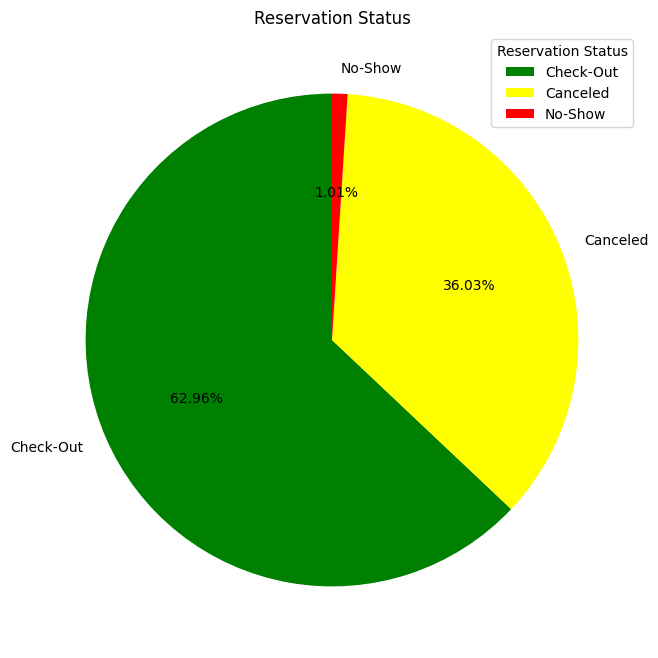

In [ ]:
reservation_stat = df['reservation_status'].value_counts()

x = reservation_stat.index
y = reservation_stat.values

plt.figure(figsize=(9, 8))
plt.pie(y, labels=x, autopct='%1.2f%%', startangle=90, colors=['green', 'yellow', 'red'])
plt.legend(title='Reservation Status')
plt.title('Reservation Status')
plt.show()

In [ ]:
#df['distribution_channel'].value_counts()
#cancelled for now, not needed now

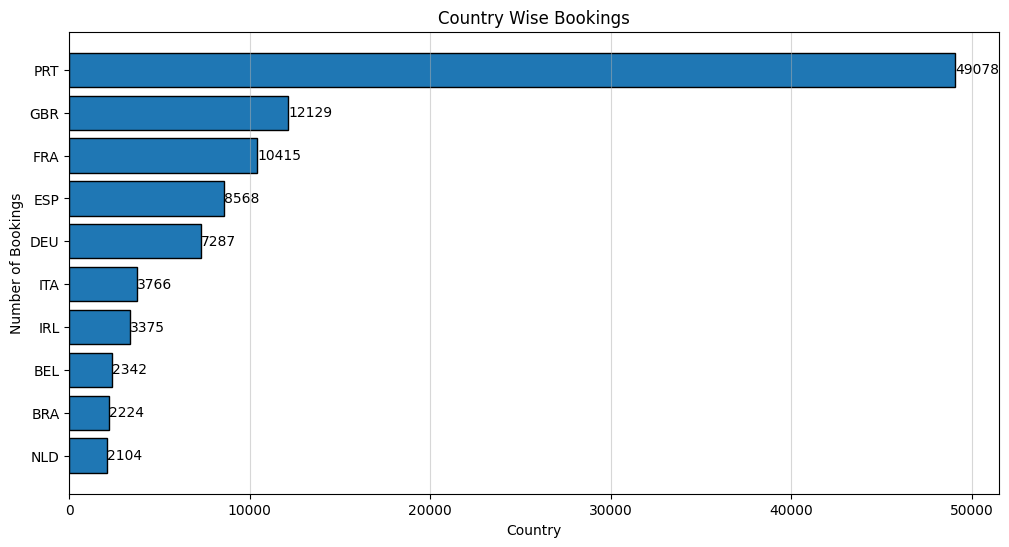

In [ ]:
df['country'] = df['country'].fillna(df['country'].mode()[0])
country_wise_bookings = df['country'].value_counts().head(10).sort_values(ascending=True)
x = country_wise_bookings.index
y = country_wise_bookings.values
plt.figure(figsize=(12, 6))
plt.barh(x, y, edgecolor='black')
plt.title('Country Wise Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.grid(axis='x', alpha=0.5, linestyle='-')
plt.show()

# Room types and comparision

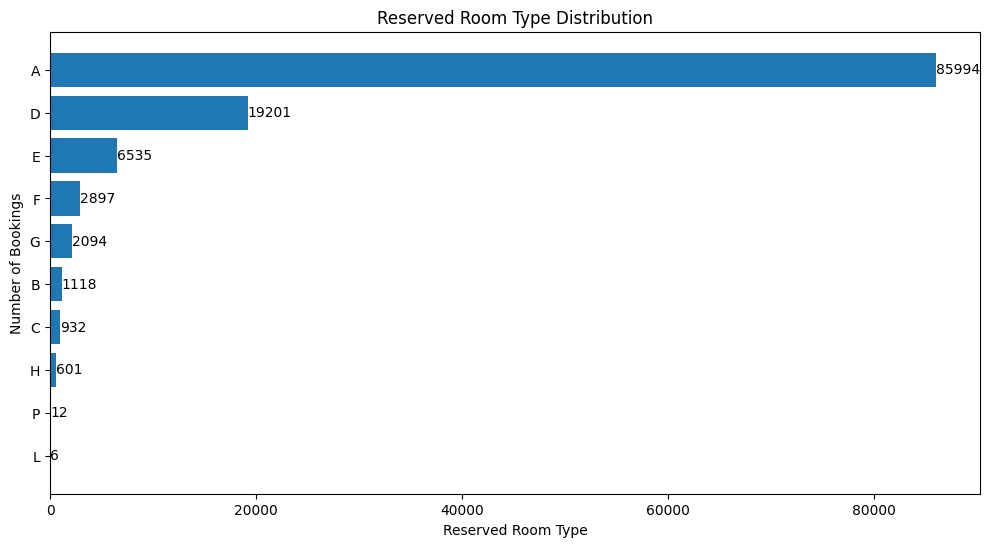

In [ ]:
reserved_room = df['reserved_room_type'].value_counts().sort_values(ascending=True)

x = reserved_room.index
y = reserved_room.values

plt.figure(figsize=(12, 6))
plt.barh(x, y)
plt.title('Reserved Room Type Distribution')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

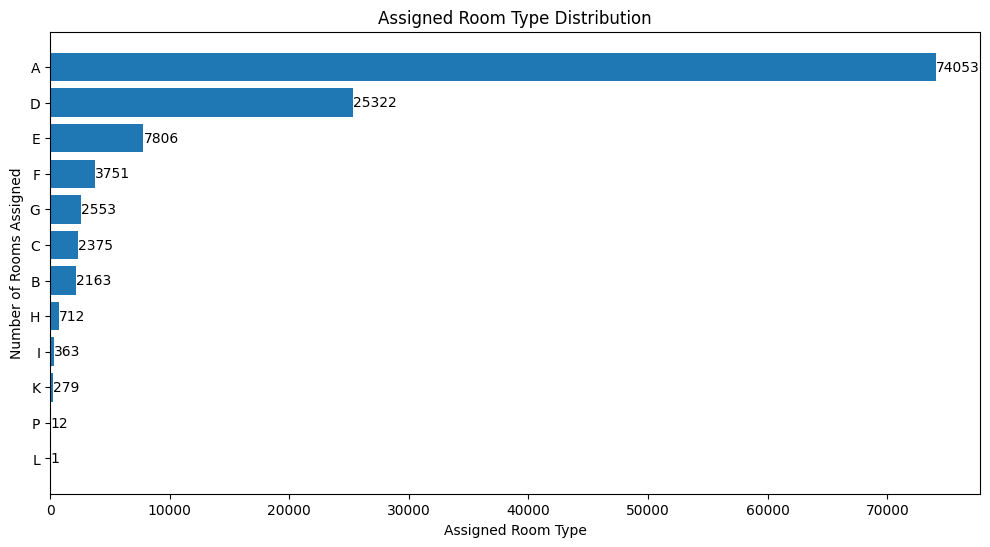

In [ ]:
assigned_room = df['assigned_room_type'].value_counts().sort_values(ascending=True)

x = assigned_room.index
y = assigned_room.values

plt.figure(figsize=(12, 6))
plt.barh(x, y)
plt.title('Assigned Room Type Distribution')
plt.xlabel('Assigned Room Type')
plt.ylabel('Number of Rooms Assigned')
plt.bar_label(plt.gca().containers[0])
plt.show()

<Figure size 1400x700 with 0 Axes>

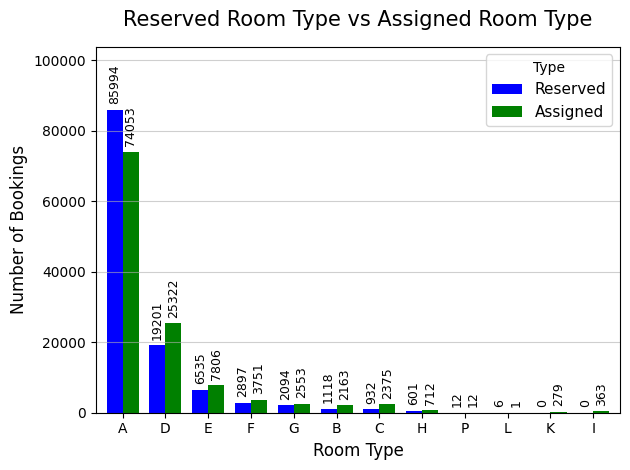

In [ ]:
reserved_counts = df['reserved_room_type'].value_counts().sort_index()
assigned_counts = df['assigned_room_type'].value_counts().sort_index()

room_comparison = pd.DataFrame({
    'Reserved': reserved_counts,
    'Assigned': assigned_counts
}).fillna(0).astype(int)

room_comparison = room_comparison.sort_values('Reserved', ascending=False)

plt.figure(figsize=(14, 7))
ax = room_comparison.plot(kind='bar', width=0.75, color=['blue', 'green'])

plt.title('Reserved Room Type vs Assigned Room Type', fontsize=15, pad=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Type', fontsize=11)
plt.grid(axis='y', linestyle='-', alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=4, rotation=90)

plt.ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

room_change
False    104473
True      14917
Name: count, dtype: int64
room_change
False    87.51
True     12.49
Name: proportion, dtype: float64


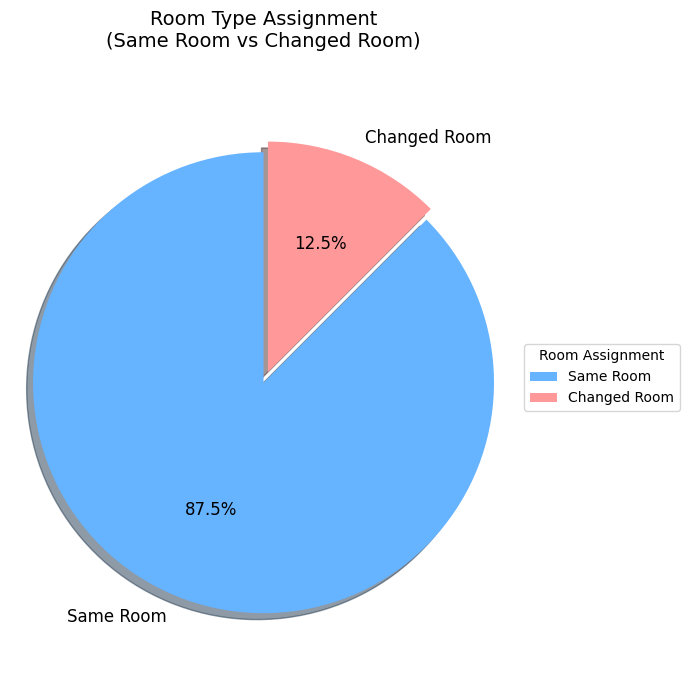

In [ ]:
df['room_change'] = df['reserved_room_type'] != df['assigned_room_type']

room_change_counts = df['room_change'].value_counts()
room_change_pct = df['room_change'].value_counts(normalize=True) * 100

print(room_change_counts)
print(room_change_pct.round(2))

plt.figure(figsize=(7, 7))
labels = ['Same Room', 'Changed Room']
sizes = [room_change_counts[False], room_change_counts[True]]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90,
        textprops={'fontsize': 12})

plt.title('Room Type Assignment\n(Same Room vs Changed Room)', fontsize=14, pad=20)
plt.axis('equal')
plt.legend(title='Room Assignment', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

<Figure size 1400x1300 with 0 Axes>

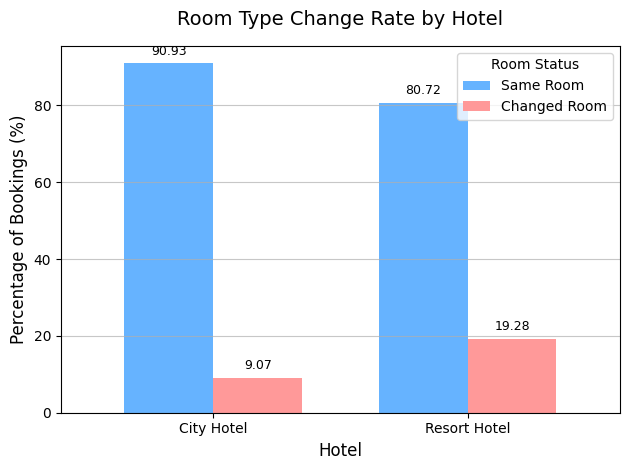

In [ ]:
summary = df.groupby(['hotel', 'room_change']).size().unstack(fill_value=0)
summary_pct = round(summary.div(summary.sum(axis=1), axis=0) * 100, 2)

plt.figure(figsize=(14, 13))
summary_pct.plot(kind='bar', color=['#66b3ff', '#ff9999'], width=0.7)

plt.title('Room Type Change Rate by Hotel', fontsize=14, pad=15)
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Percentage of Bookings (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Same Room', 'Changed Room'], title='Room Status')

for container in plt.gca().containers:
    plt.bar_label(container, fontsize=9, padding=4)

plt.grid(axis='y', linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# bdf.groupby(['hotel', 'room_change']).size().unstack(fill_value=0)

# People and Stay Duration

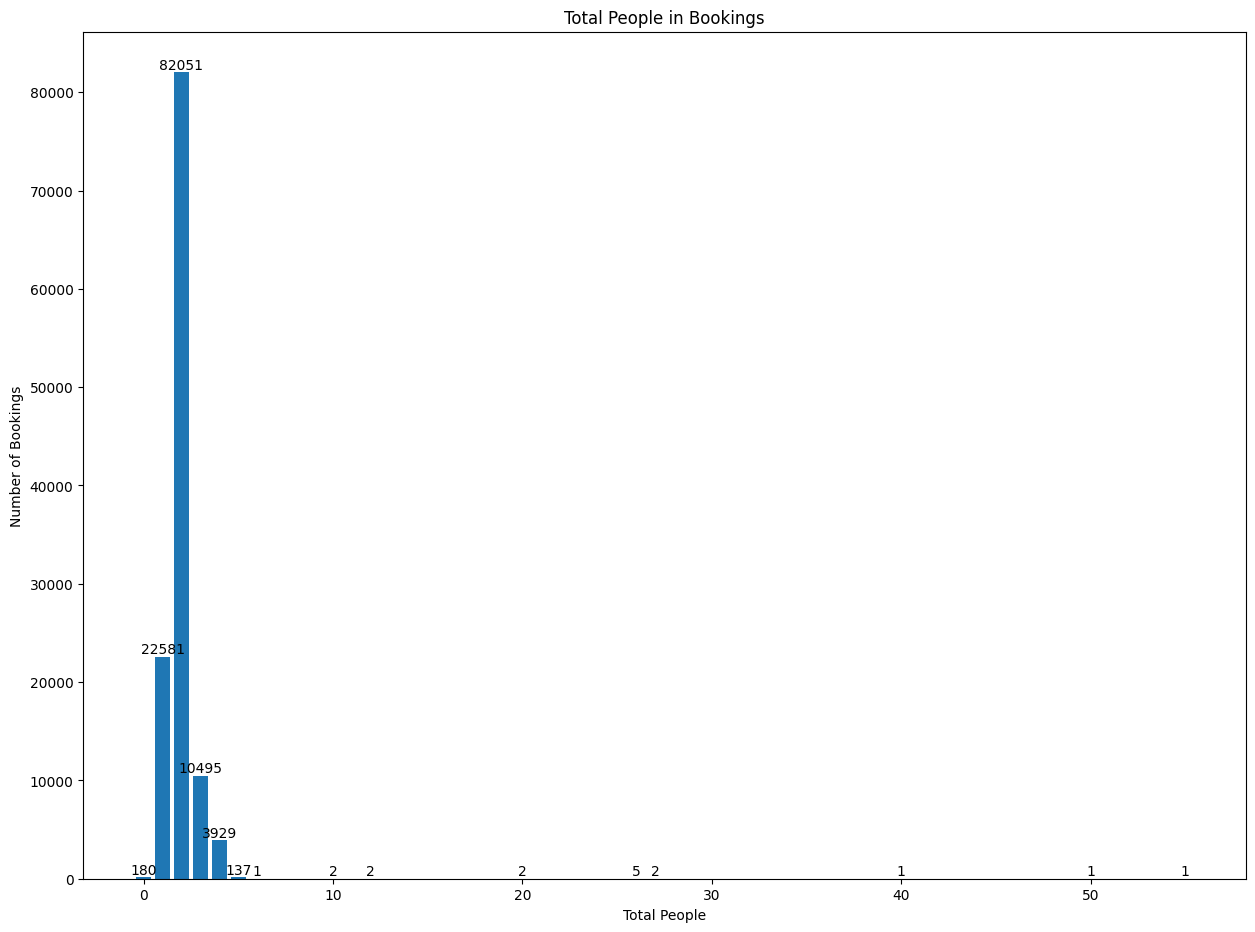

In [ ]:
df['total_people'] = df['adults'] + df['children'].fillna(df['children'].median()) + df['babies']
total_people = df['total_people'].value_counts().sort_index()
x = total_people.index
y = total_people.values

plt.figure(figsize=(15, 11))
plt.bar(x, y)
plt.title('Total People in Bookings')
plt.xlabel('Total People')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

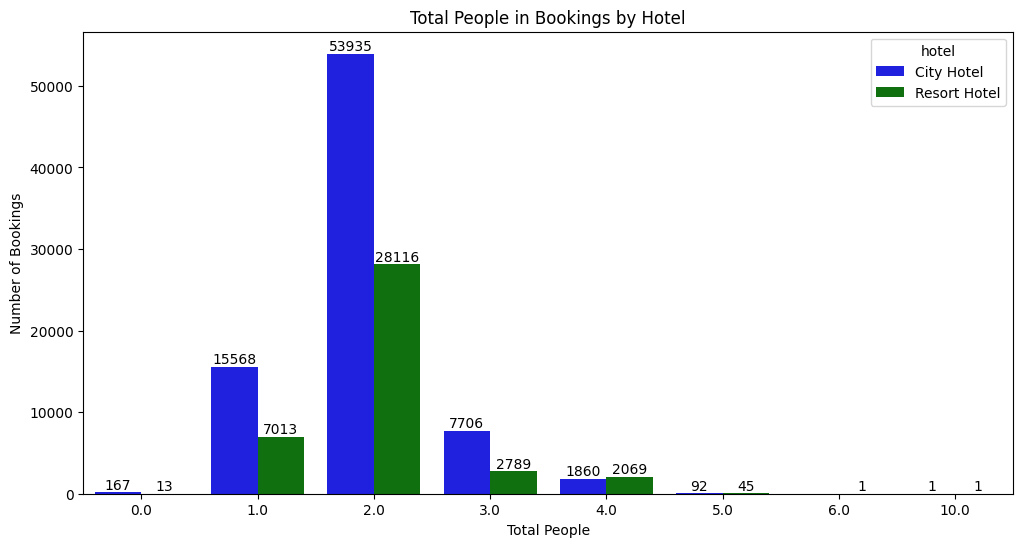

In [ ]:
df_temp = df[df['total_people'] <= 10]
summary = df_temp.groupby(['hotel', 'total_people']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.barplot(data=summary, x='total_people', y='count', hue='hotel', palette=['blue', 'green'])
plt.xlabel('Total People')
plt.ylabel('Number of Bookings')
plt.title('Total People in Bookings by Hotel')
for container in plt.gca().containers:
  plt.bar_label(container)

plt.show()

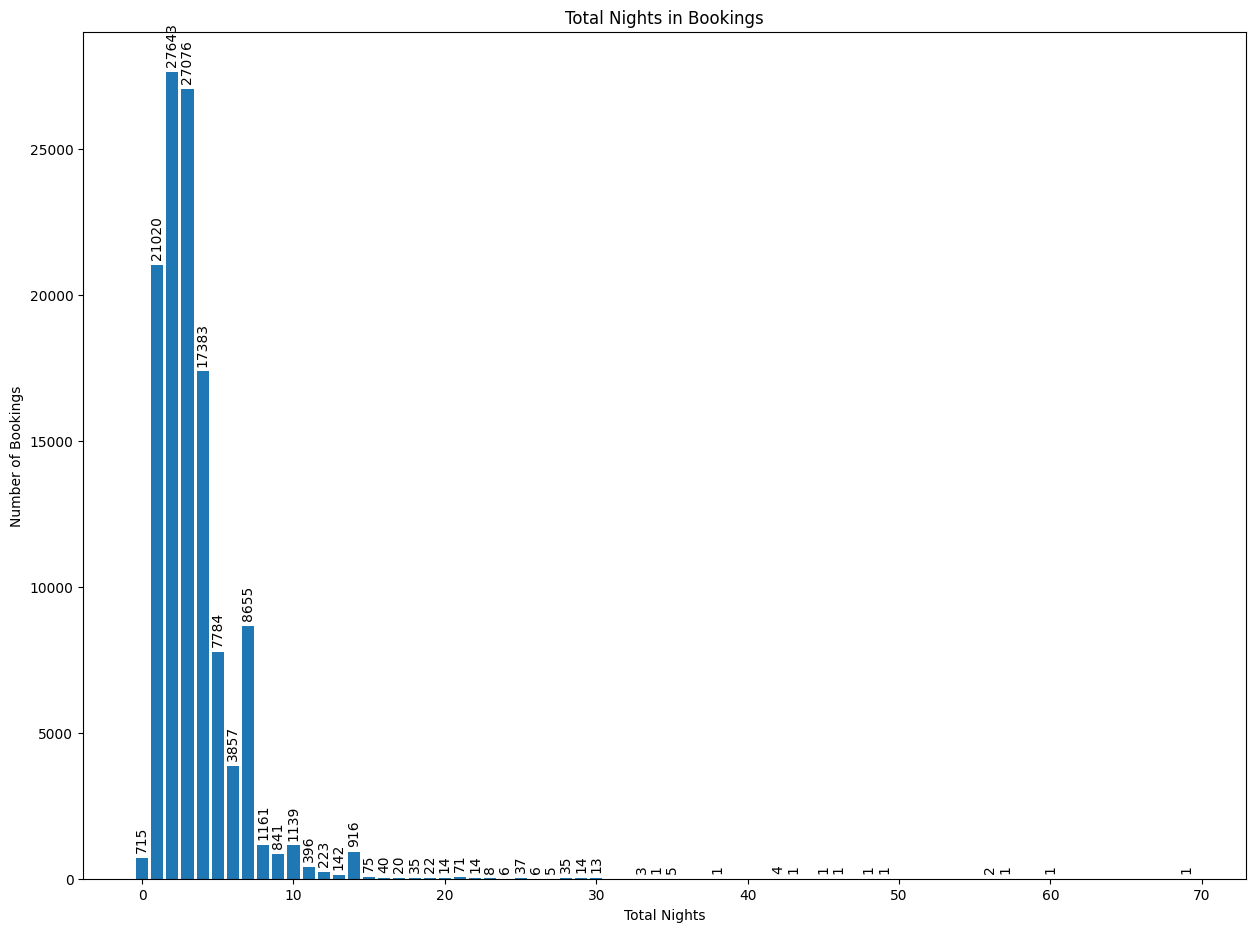

In [ ]:
df['stays_in_total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
total_nights = df['stays_in_total_nights'].value_counts()

x = total_nights.index
y = total_nights.values

plt.figure(figsize=(15, 11))
plt.bar(x, y)
plt.title('Total Nights in Bookings')
plt.xlabel('Total Nights')
plt.bar_label(plt.gca().containers[0], rotation=90, padding=4)
plt.ylabel('Number of Bookings')

plt.show()

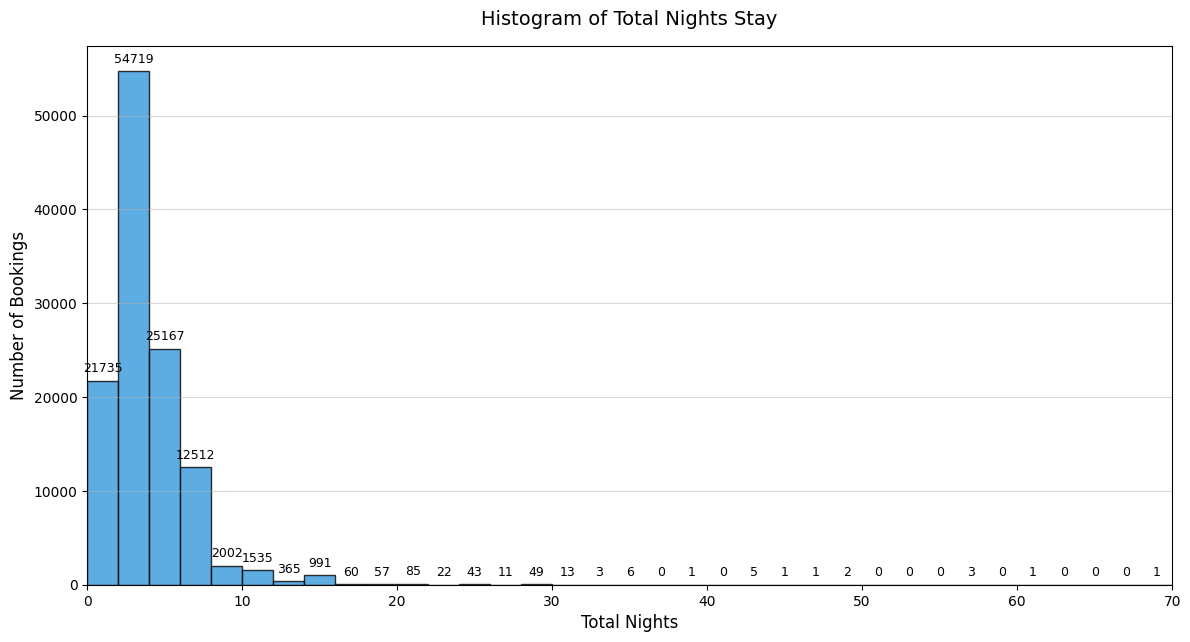

In [ ]:
# Calculate the range of stays_in_total_nights
min_nights = int(df['stays_in_total_nights'].min())
max_nights = int(df['stays_in_total_nights'].max())

# Create bins with a step size (bin width) of 2
bins = range(min_nights, max_nights + 2, 2)

plt.figure(figsize=(14, 7))
plt.hist(df['stays_in_total_nights'], bins=bins, edgecolor='black', color='#3498db', alpha=0.8)

plt.title('Histogram of Total Nights Stay', fontsize=14, pad=15)
plt.xlabel('Total Nights', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xlim(min_nights, max_nights + 1)  # Limiting x-axis to 30 for better visibility as most stays are short-term
plt.bar_label(plt.gca().containers[0] if len(plt.gca().containers) > 0 else "", fontsize=9, padding=4)
plt.grid(axis='y', linestyle='-', alpha=0.5)

plt.show()

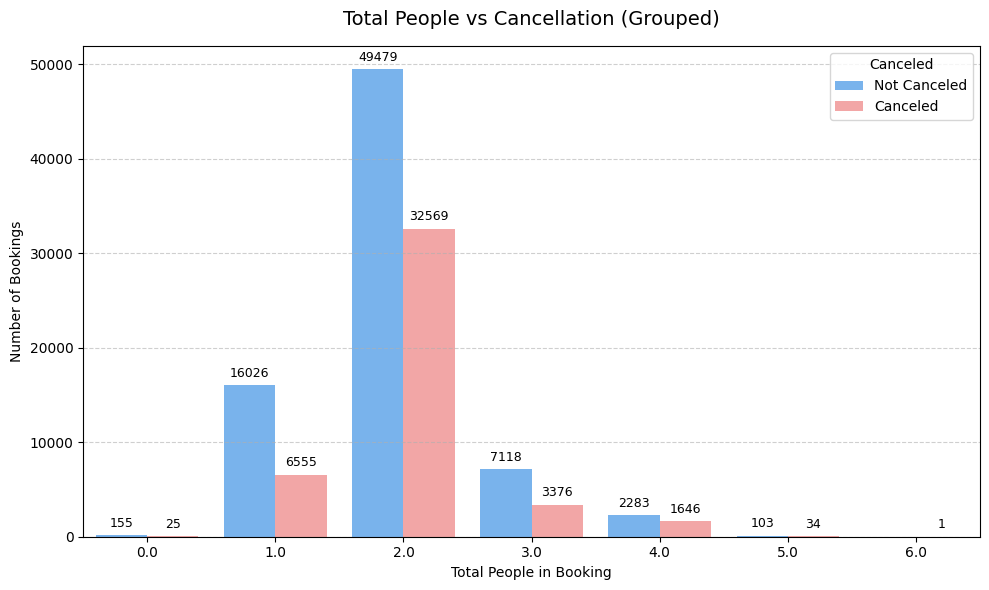

In [ ]:
df_temp = df[df['total_people'] <= 6].copy()

# Count for total and canceled
# total_counts = df_temp['total_people'].value_counts().sort_index()
# canceled_counts = df_temp[df_temp['is_canceled'] == 1]['total_people'].value_counts().sort_index()

# plt.figure(figsize=(10, 6))

# # 1st choice
# plt.bar(total_counts.index, total_counts.values,
#         color='#66b3ff', label='Total Bookings', width=0.6, alpha=0.7)

# # Canceled bars overlapping on top
# plt.bar(canceled_counts.index, canceled_counts.values,
#         color='#ff9999', label='Canceled', width=0.6, alpha=0.8)

# plt.title('Total People vs Cancellation (Overlapping)', fontsize=14, pad=15)
# plt.xlabel('Total People in Booking')
# plt.ylabel('Number of Bookings')
# plt.legend()
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# for container in plt.gca().containers:
#     plt.bar_label(container, fontsize=9, padding=4)
# plt.tight_layout()
# plt.show()

# # Create percentage summary - 2nd choice
# summary = df_temp.groupby(['total_people', 'is_canceled']).size().unstack(fill_value=0)
# summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

# plt.figure(figsize=(10, 6))
# summary_pct.plot(kind='bar', stacked=True, color=['#66b3ff', '#ff9999'], width=0.7)

# plt.title('Cancellation Rate by Total People (Stacked %)', fontsize=14, pad=15)
# plt.xlabel('Total People in Booking')
# plt.ylabel('Percentage (%)')
# plt.xticks(rotation=0)
# plt.legend(title='Canceled', labels=['Not Canceled', 'Canceled'])
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# for container in plt.gca().containers:
#     plt.bar_label(container, fontsize=9, padding=4)
# plt.tight_layout()
# plt.show()

# 3rd choice
plt.figure(figsize=(10, 6))
sns.countplot(data=df_temp, x='total_people', hue='is_canceled',
              palette=['#66b3ff', '#ff9999'])

plt.title('Total People vs Cancellation (Grouped)', fontsize=14, pad=15)
plt.xlabel('Total People in Booking')
plt.ylabel('Number of Bookings')
plt.legend(title='Canceled', labels=['Not Canceled', 'Canceled'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=9, padding=4)
plt.tight_layout()
plt.show()

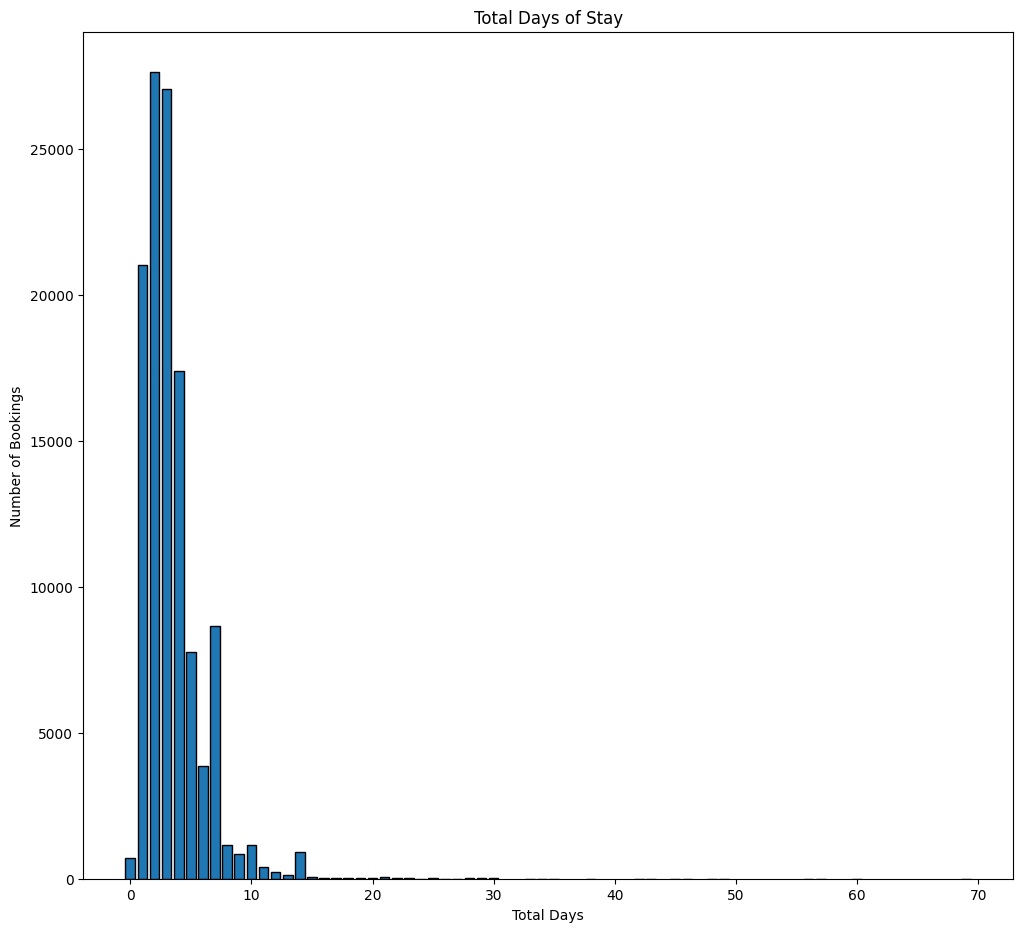

In [ ]:
total_days = (df['stays_in_weekend_nights'] + df['stays_in_week_nights']).value_counts().sort_index()
x = total_days.index
y = total_days.values
plt.figure(figsize=(12, 11))
plt.bar(x, y, edgecolor='black')
plt.title('Total Days of Stay')
plt.xlabel('Total Days')
plt.ylabel('Number of Bookings')
plt.show()

#

# Distributions & Outliers (Advanced – Unit 4 style)


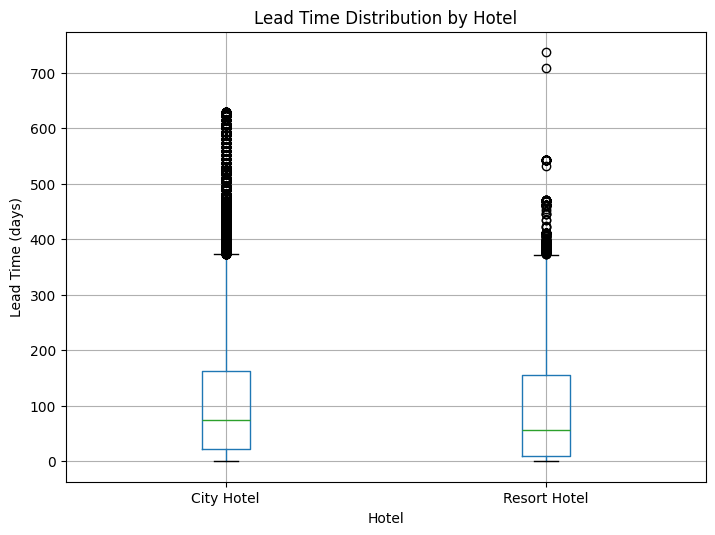

In [ ]:
df.boxplot(
    column='lead_time',
    by='hotel',
    figsize=(8, 6)
)

plt.title('Lead Time Distribution by Hotel')
plt.suptitle('')
plt.xlabel('Hotel')
plt.ylabel('Lead Time (days)')

plt.show()

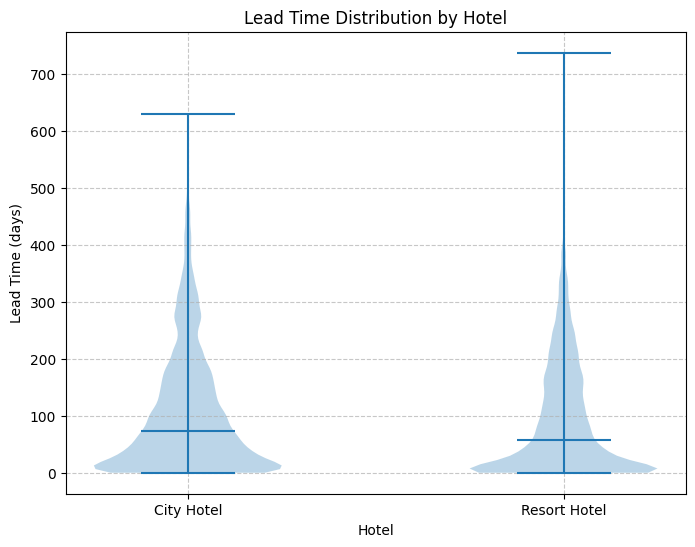

In [ ]:
city_hotel = df[df['hotel'] == 'City Hotel']['lead_time']
resort_hotel = df[df['hotel'] == 'Resort Hotel']['lead_time']

plt.figure(figsize=(8, 6))

plt.violinplot(
    [city_hotel, resort_hotel],
    showmedians=True
)

plt.xticks(
    [1, 2],
    ['City Hotel', 'Resort Hotel']
)

plt.title('Lead Time Distribution by Hotel')
plt.xlabel('Hotel')
plt.ylabel('Lead Time (days)')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

<Figure size 800x600 with 0 Axes>

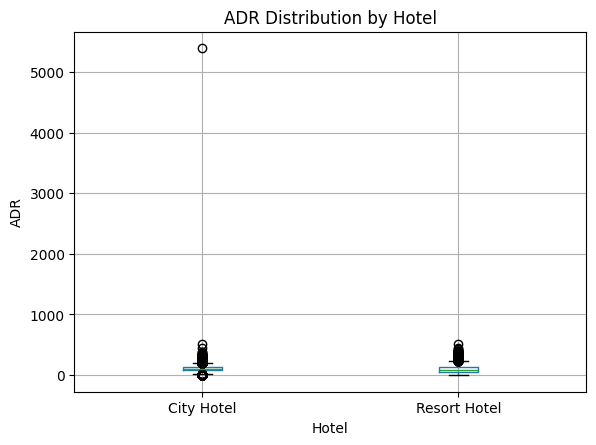

In [ ]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column='adr',
    by='hotel'
)

plt.title('ADR Distribution by Hotel')
plt.suptitle('')
plt.xlabel('Hotel')
plt.ylabel('ADR')

plt.show()

<Figure size 800x600 with 0 Axes>

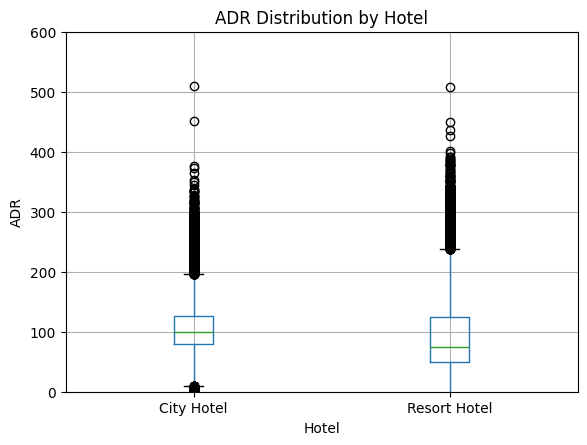

In [ ]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column='adr',
    by='hotel'
)

plt.title('ADR Distribution by Hotel')
plt.suptitle('')
plt.xlabel('Hotel')
plt.ylabel('ADR')
plt.ylim(0, 600)

plt.show()

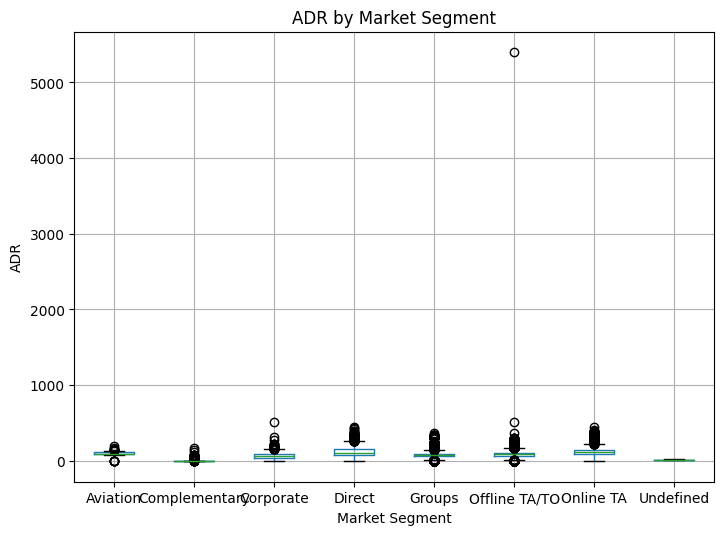

In [ ]:
df.boxplot(
    column='adr',
    by='market_segment',
    figsize=(8, 6)
)

plt.title('ADR by Market Segment')
plt.suptitle('')
plt.xlabel('Market Segment')
plt.ylabel('ADR')

plt.show()

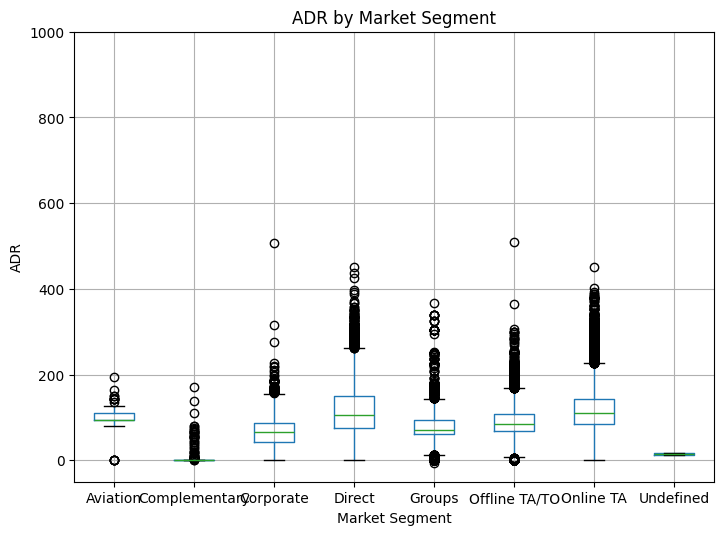

In [ ]:
df.boxplot(
    column='adr',
    by='market_segment',
    figsize=(8, 6)
)

plt.title('ADR by Market Segment')
plt.suptitle('')
plt.xlabel('Market Segment')
plt.ylabel('ADR')
plt.ylim(-50, 1000) #Excluding the one outlier

plt.show()

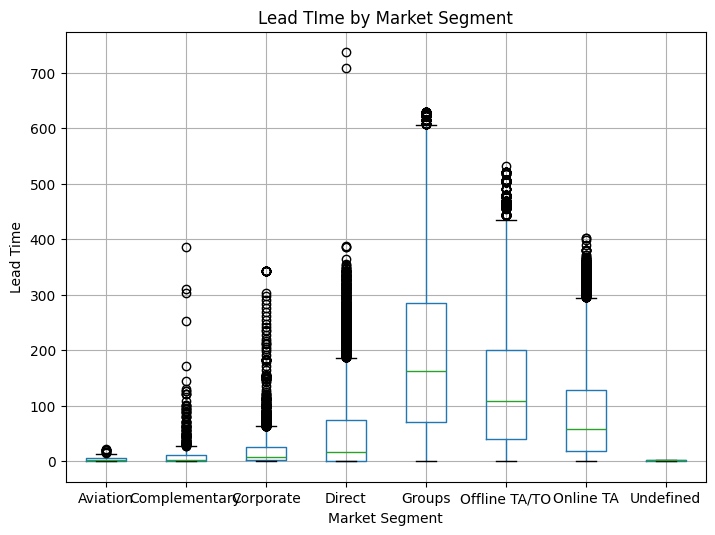

In [ ]:
df.boxplot(
    column='lead_time',
    by='market_segment',
    figsize=(8, 6)
)

plt.title('Lead TIme by Market Segment')
plt.suptitle('')
plt.xlabel('Market Segment')
plt.ylabel('Lead Time')

plt.show()

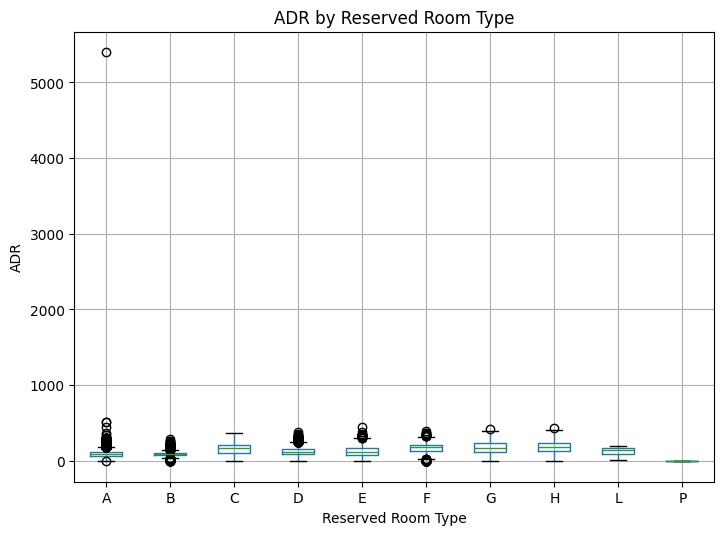

In [ ]:
df.boxplot(
    column='adr',
    by='reserved_room_type',
    figsize=(8, 6)
)

plt.title('ADR by Reserved Room Type')
plt.suptitle('')
plt.xlabel('Reserved Room Type')
plt.ylabel('ADR')

plt.show()

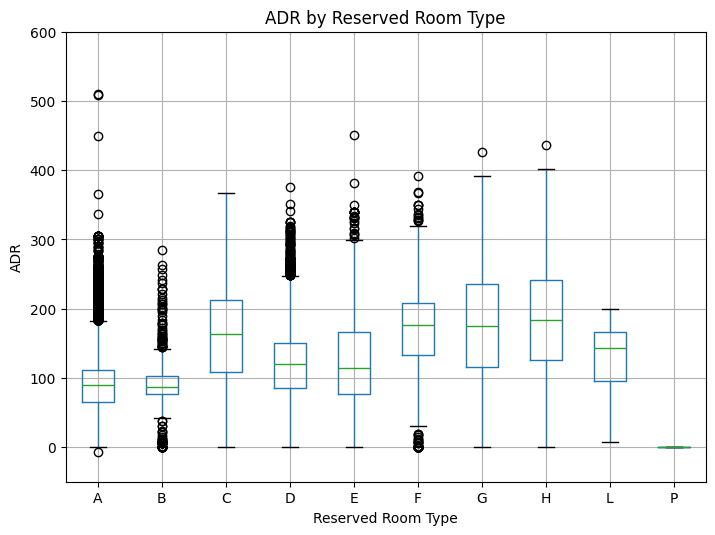

In [ ]:
df.boxplot(
    column='adr',
    by='reserved_room_type',
    figsize=(8, 6)
)

plt.title('ADR by Reserved Room Type')
plt.suptitle('')
plt.xlabel('Reserved Room Type')
plt.ylabel('ADR')
plt.ylim(-50, 600)

plt.show()

In [ ]:
#days in waiting list per hotel
#print(df['days_in_waiting_list'].value_counts())

days_in_waiting_list
0      115692
1          12
2           5
3          59
4          25
        ...  
236        35
259        10
330        15
379        15
391        45
Name: count, Length: 128, dtype: int64


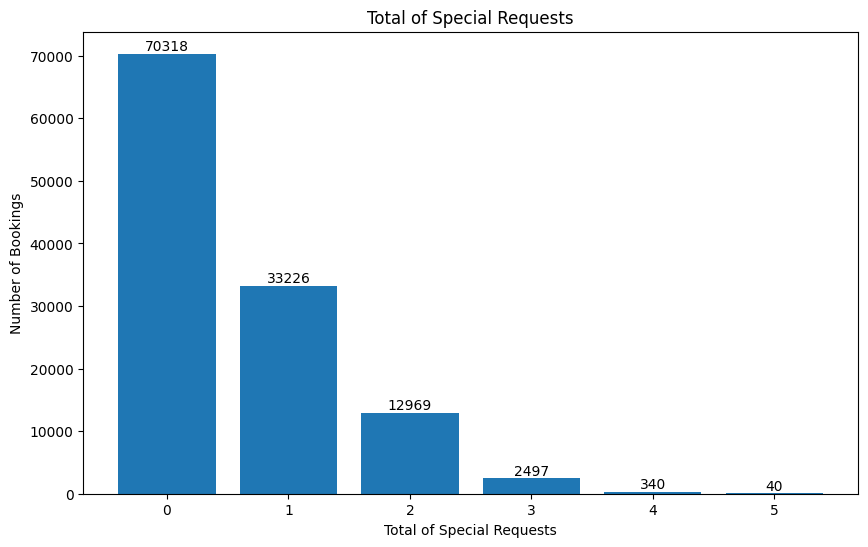

In [ ]:
sepcial_requests = df['total_of_special_requests'].value_counts()
x = sepcial_requests.index
y = sepcial_requests.values

plt.figure(figsize=(10, 6))
plt.bar(x, y)
plt.title('Total of Special Requests')
plt.xlabel('Total of Special Requests')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

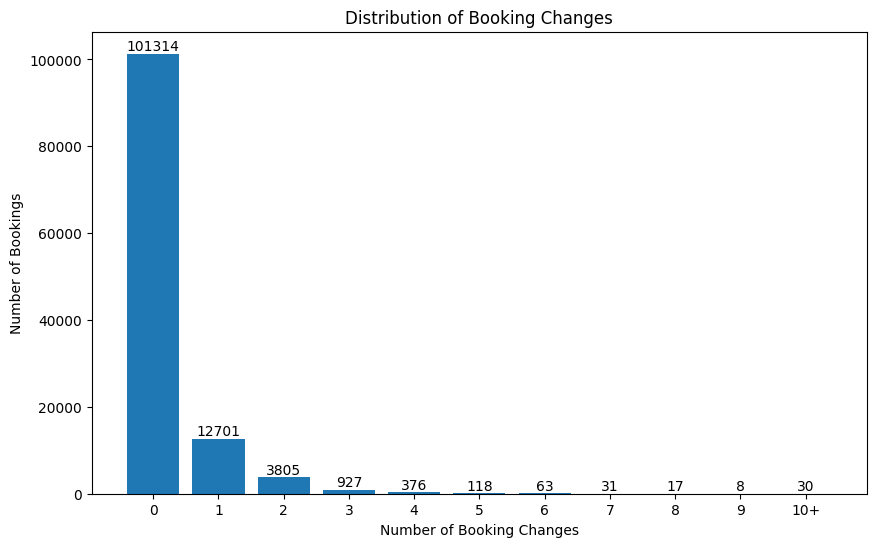

In [ ]:
#df['booking_changes'].value_counts()
booking_changes = pd.DataFrame(
    #add 10+ index values and make a seprate entry for just that
    df['booking_changes'].value_counts().sort_index()[:10]
)
booking_changes.loc['10+'] = df['booking_changes'].value_counts().sort_index()[10:].sum()

# booking_changes.plot(
#     kind='bar',
#     figsize=(10, 6),
#     legend=False
# )
plt.figure(figsize=(10, 6))

x = booking_changes.index.astype(str)
y = booking_changes['count']
plt.bar(x, y)
plt.title('Distribution of Booking Changes')
plt.xlabel('Number of Booking Changes')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.bar_label(plt.gca().containers[0])
plt.show()

In [ ]:
booking_changes

,count
booking_changes,
0,101314
1,12701
2,3805
3,927
4,376
5,118
6,63
7,31
8,17


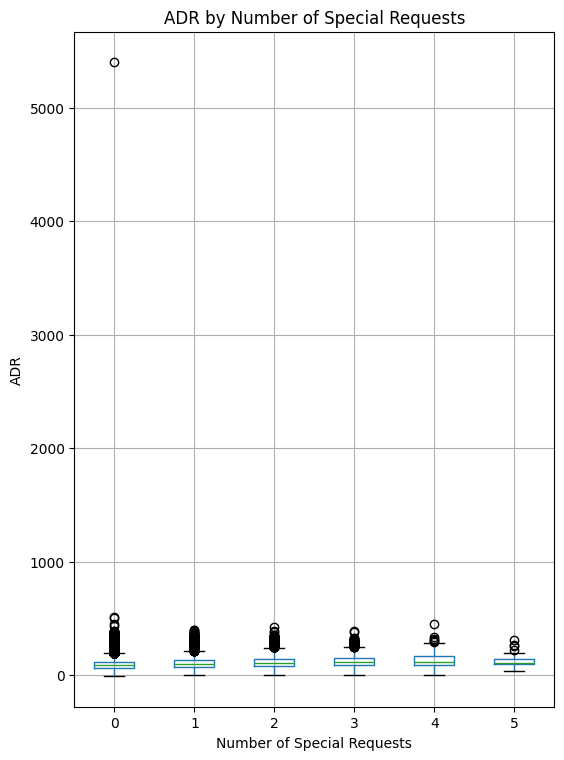

In [ ]:
# df.boxplot(
#     column='adr',
#     by='total_of_special_requests',
#     figsize=(6, 9)
# )

# plt.title('ADR by Number of Special Requests')
# plt.suptitle('')
# plt.xlabel('Number of Special Requests')
# plt.ylabel('ADR')
# plt.show()

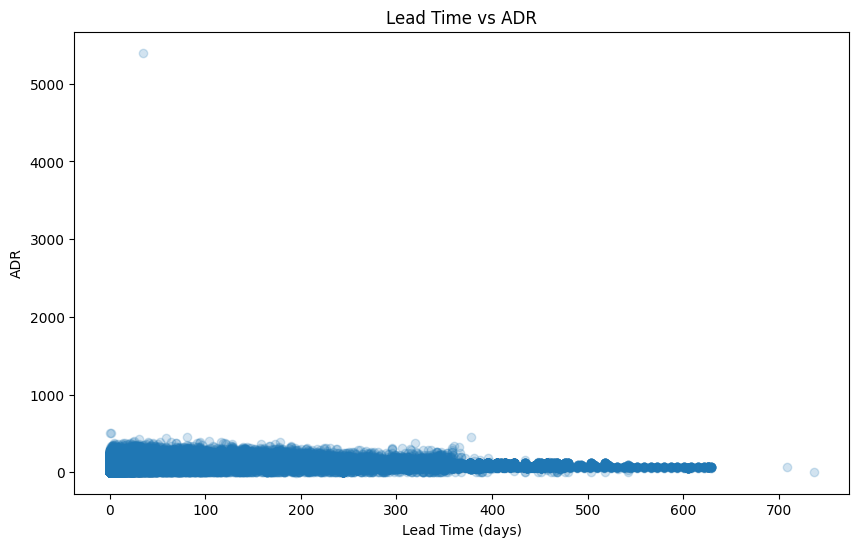

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['lead_time'],
    df['adr'],
    alpha=0.2
)

plt.title('Lead Time vs ADR')
plt.xlabel('Lead Time (days)')
plt.ylabel('ADR')

plt.show()

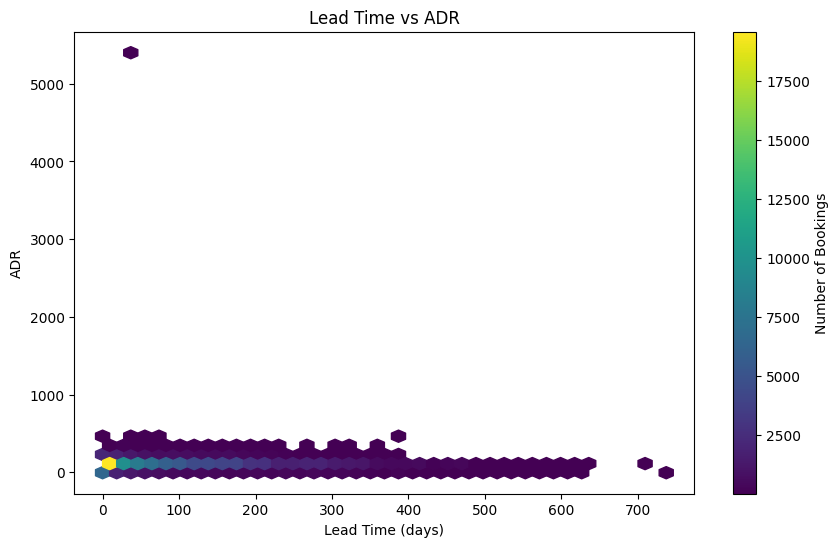

In [ ]:
plt.figure(figsize=(10, 6))

plt.hexbin(
    df['lead_time'],
    df['adr'],
    gridsize=40,
    mincnt=1
)

plt.colorbar(label='Number of Bookings')

plt.title('Lead Time vs ADR')
plt.xlabel('Lead Time (days)')
plt.ylabel('ADR')

plt.show()

In [ ]:
display(df['previous_cancellations'].value_counts())
display(df['lead_time'].value_counts())

,count
previous_cancellations,
0,112906
1,6051
2,116
3,65
24,48
11,35
4,31
26,26
25,25


,count
lead_time,
0,6345
1,3460
2,2069
3,1816
4,1715
...,...
435,1
532,1
371,1


#

# Merge arrival date columns into one column

In [ ]:
year = df['arrival_date_year'].astype(str)
month = df['arrival_date_month'].astype(str)
day = df['arrival_date_day_of_month'].astype(str)

# Make a new revised column
temp_dates = pd.to_datetime(year + '-' + month + '-' + day, format='%Y-%B-%d')
df['arrival_date'] = temp_dates.dt.strftime('%Y-%m-%d')

# Drop the rest of the columns
df = df.drop(['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], axis=1)


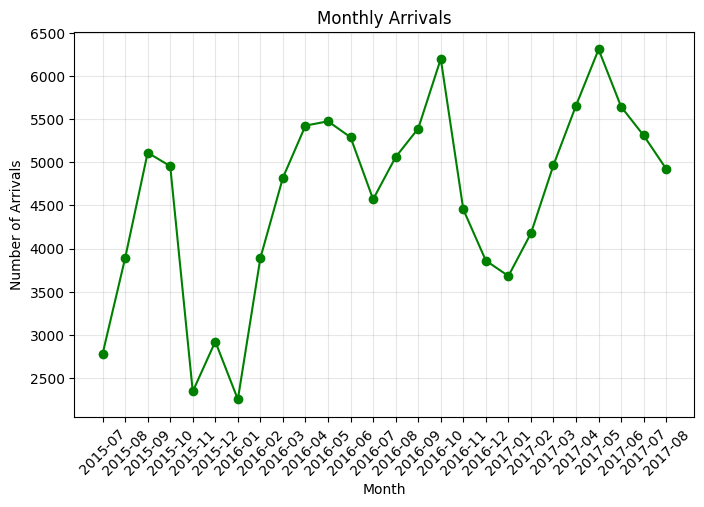

In [ ]:
df['arrival_year_month'] = df['arrival_date'].str[:7]

monthly_arrivals = df['arrival_year_month'].value_counts().sort_index()
x = monthly_arrivals.index
y = monthly_arrivals.values

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='green')
plt.xlabel('Month')
plt.ylabel('Number of Arrivals')
plt.title('Monthly Arrivals')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
total_people

,count
total_people,
0.0,180
1.0,22581
2.0,82048
3.0,10494
4.0,3929
5.0,137
6.0,1
10.0,2
12.0,2


In [ ]:
df['market_segment'].value_counts()

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


In [ ]:
df['reserved_room_type'].value_counts()

,count
reserved_room_type,
A,85994
D,19201
E,6535
F,2897
G,2094
B,1118
C,932
H,601
P,12


In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_week_number',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card', 'room_change', 'total_people',
       'stays_in_total_nights', 'arrival_date', 'arrival_year_month'],
      dtype='object')

1. Hotel vs number_of_people : bar chart - done
2. number of people - is_cancelled vs is_not_cancelled : pie_chart
    (represent precentages) - done
3. leadtime vs hotel_name : box/violin plot - done
4. merge arrival_date_year, arrival_date_month, arrival_date_day_of_month --> arrival_date - done

5. no_of_people vs stay_in_weekend_nights/stay_in_week_nights : bar/pie plot --**done partially

6. adults + babies + childern --> total_people (generate new col) --**done partially

7. count vs meal : bar chart - done
8. country : bar chart - done
9. market_segment : pie chart - done
10. is_repeated_guest : pie - done
11. reserved_room_type: bar/pie
12. assigned_room_type and reserved_room_type : side by side bar chart
13. deposit_type w.r.t each hotel : side by side bar plot (for each hotel three deposit_types)three
14. chanchange the type of agent id from float to int/strge the type of agent id from float to int/str
15. change the type of company from float to int/str
16. days_in_waiting_list : one histogram per hotel
17. customer_type vs assigned_room_type : bar chart
18. adr vs assigned_room_type : bar chart
19. required_car_parking_spaces vs customer_type : bar
20. total_of_special_requests vs adr : heatmap
21. reservation_status : bar (depends on what can once be thought)